In [1]:
import sys
import os

if 'google.colab' in sys.modules:
    print("☁️ Google Colab detected. Setting up GitHub repository...")
    if not os.path.exists('manero-panganiban-serafica'):
        !git clone https://github.com/kricme/manero-panganiban-serafica.git
    if not os.getcwd().endswith('04 Transformer-based Sentiment Analysis/0402 Fine-tuned BERT models'):
        %cd "manero-panganiban-serafica/04 Transformer-based Sentiment Analysis/0402 Fine-tuned BERT models"
else:
    print("💻 Local environment detected. Using local file paths.")

☁️ Google Colab detected. Setting up GitHub repository...
Cloning into 'manero-panganiban-serafica'...
remote: Enumerating objects: 162, done.
remote: Counting objects: 100% (162/162), done.
remote: Compressing objects: 100% (136/136), done.
remote: Total 162 (delta 58), reused 62 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (162/162), 23.35 MiB | 14.87 MiB/s, done.
Resolving deltas: 100% (58/58), done.
/content/manero-panganiban-serafica/04 Transformer-based Sentiment Analysis/0402 Fine-tuned BERT models


In [2]:
import os, random, numpy as np, pandas as pd, torch
from tqdm import tqdm
import nltk
from nltk.tokenize import sent_tokenize
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from torch.optim import AdamW


# File Paths
LABELED_CSV         = "../../00 Original Dataset/speech dataset/labeled_sentences_1.csv"
SPEECHES_CSV        = "../../00 Cleaned Dataset/01 speech dataset/bsp_speech_dataset.csv"
SAVE_MODEL_DIR      = "finetuned_roberta_bsp_sent"
OUT_DIR             = "../../00 Cleaned Dataset/02 fine-tuned bert results"

# Column Names
TEXT_COL_LABELED    = "sentence"
LABEL_COL_LABELED   = "label"                 # must be in {negative, neutral, positive}
TEXT_COL_SPEECHES   = "Text"
ID_COL_SPEECHES     = "index"
DATE_COL_SPEECHES   = "Date"

# Training Hyperparams
BASE_MODEL          = "roberta-base"
MAX_LENGTH_TRAIN    = 256
BATCH_SIZE_TRAIN    = 16
EPOCHS              = 5
LR                  = 2e-5
WEIGHT_DECAY        = 0.01
WARMUP_STEPS        = 0
SEED                = 42

# Scoring Hyperparams
MAX_LENGTH_SCORE    = 512
BATCH_SIZE_SCORE    = 32

# Dixed Sentiment Label Order
LABEL_ORDER = ["negative", "neutral", "positive"]  # required

# Setup
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
os.makedirs(SAVE_MODEL_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

try: nltk.data.find("tokenizers/punkt")
except LookupError: nltk.download("punkt")
try: nltk.data.find("tokenizers/punkt_tab")
except LookupError:
    try: nltk.download("punkt_tab")
    except: pass

device = "cuda" if torch.cuda.is_available() else "cpu"
device

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


'cuda'

In [3]:
# Load labeled sentences
df_lab = pd.read_csv(LABELED_CSV).dropna(subset=[TEXT_COL_LABELED, LABEL_COL_LABELED]).copy()

# Validate labels are exactly negative/neutral/positive (any case accepted)
df_lab[LABEL_COL_LABELED] = df_lab[LABEL_COL_LABELED].str.lower().str.strip()
unknown = set(df_lab[LABEL_COL_LABELED].unique()) - set(LABEL_ORDER)
if unknown:
    raise ValueError(f"Found unknown labels {unknown}. Labels must be exactly {LABEL_ORDER}.")

label2id = {lab:i for i, lab in enumerate(LABEL_ORDER)}
id2label = {v:k for k,v in label2id.items()}

df_lab["label_id"] = df_lab[LABEL_COL_LABELED].map(label2id)

from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(
    df_lab, test_size=0.2, random_state=SEED, stratify=df_lab["label_id"]
)

len(train_df), len(val_df), train_df[LABEL_COL_LABELED].value_counts()


(3640,
 910,
 label
 positive    1734
 neutral     1646
 negative     260
 Name: count, dtype: int64)

In [4]:
tok = AutoTokenizer.from_pretrained(BASE_MODEL)

class SentDataset(Dataset):
    def __init__(self, df, text_col, label_col_id, tokenizer, max_length):
        self.texts = df[text_col].tolist()
        self.labels = df[label_col_id].astype(int).tolist()
        self.tok = tokenizer
        self.max_length = max_length
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, i):
        enc = self.tok(
            self.texts[i],
            truncation=True, max_length=self.max_length, padding=False,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k,v in enc.items()}
        item["labels"] = torch.tensor(self.labels[i], dtype=torch.long)
        return item

def collate_fn_factory(tokenizer):
    def collate_fn(batch):
        keys = batch[0].keys()
        to_pad = {k: [b[k] for b in batch] for k in keys}
        return tokenizer.pad(to_pad, padding=True, return_tensors="pt")
    return collate_fn

train_ds = SentDataset(train_df, TEXT_COL_LABELED, "label_id", tok, MAX_LENGTH_TRAIN)
val_ds   = SentDataset(val_df,   TEXT_COL_LABELED, "label_id", tok, MAX_LENGTH_TRAIN)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE_TRAIN, shuffle=True,  collate_fn=collate_fn_factory(tok))
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE_TRAIN, shuffle=False, collate_fn=collate_fn_factory(tok))

len(train_dl), len(val_dl)


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

(228, 57)

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=len(LABEL_ORDER),
    id2label=id2label,
    label2id=label2id,
).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

num_training_steps = EPOCHS * len(train_dl)

scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=num_training_steps
)


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [6]:
def metrics_from_preds(preds, labels, num_labels):
    preds = np.asarray(preds); labels = np.asarray(labels)
    acc = (preds == labels).mean() if len(labels) else 0.0
    f1s = []
    for c in range(num_labels):
        tp = np.sum((preds==c) & (labels==c))
        fp = np.sum((preds==c) & (labels!=c))
        fn = np.sum((preds!=c) & (labels==c))
        prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
        rec  = tp/(tp+fn) if (tp+fn)>0 else 0.0
        f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
        f1s.append(f1)
    return {"accuracy": float(acc), "f1_macro": float(np.mean(f1s))}

best_f1 = -1.0

for ep in range(1, EPOCHS+1):
    # Train
    model.train()
    tr_loss = 0.0
    for batch in tqdm(train_dl, desc=f"Epoch {ep}/{EPOCHS} - train"):
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(**batch)
        loss = loss_fn(out.logits, batch["labels"])
        loss.backward()
        tr_loss += loss.item()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
    tr_loss /= max(1, len(train_dl))

    # Validate
    model.eval()
    val_loss = 0.0
    preds_all, labels_all = [], []
    with torch.no_grad():
        for batch in tqdm(val_dl, desc=f"Epoch {ep}/{EPOCHS} - val"):
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(**batch)
            loss = loss_fn(out.logits, batch["labels"])
            val_loss += loss.item()
            preds = out.logits.argmax(dim=-1).cpu().numpy().tolist()
            lbls  = batch["labels"].cpu().numpy().tolist()
            preds_all.extend(preds); labels_all.extend(lbls)
    val_loss /= max(1, len(val_dl))
    m = metrics_from_preds(preds_all, labels_all, len(LABEL_ORDER))
    print(f"Epoch {ep:02d} | train_loss {tr_loss:.4f} | val_loss {val_loss:.4f} | "
          f"acc {m['accuracy']:.3f} | f1_macro {m['f1_macro']:.3f}")

    # Save best
    if m["f1_macro"] > best_f1:
        best_f1 = m["f1_macro"]
        model.save_pretrained(SAVE_MODEL_DIR)
        tok.save_pretrained(SAVE_MODEL_DIR)
        with open(os.path.join(SAVE_MODEL_DIR, "labels.txt"), "w") as f:
            for lab in LABEL_ORDER: f.write(lab + "\n")
        print(f"  ↳ Saved best to {SAVE_MODEL_DIR} (f1_macro={best_f1:.3f})")


Epoch 1/5 - val: 100%|██████████| 57/57 [00:03<00:00, 15.11it/s]


Epoch 01 | train_loss 0.7556 | val_loss 0.5588 | acc 0.755 | f1_macro 0.753


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ↳ Saved best to finetuned_roberta_bsp_sent (f1_macro=0.753)


Epoch 2/5 - val: 100%|██████████| 57/57 [00:04<00:00, 13.88it/s]


...

Epoch 03 | train_loss 0.4011 | val_loss 0.5752 | acc 0.764 | f1_macro 0.762


Epoch 4/5 - val: 100%|██████████| 57/57 [00:03<00:00, 16.07it/s]


Epoch 04 | train_loss 0.2763 | val_loss 0.6326 | acc 0.738 | f1_macro 0.716


Epoch 5/5 - val: 100%|██████████| 57/57 [00:03<00:00, 15.91it/s]

Epoch 05 | train_loss 0.1880 | val_loss 0.6877 | acc 0.749 | f1_macro 0.735


In [7]:
# Load fine-tuned model
clf_tok = AutoTokenizer.from_pretrained(SAVE_MODEL_DIR)
clf_mdl = AutoModelForSequenceClassification.from_pretrained(SAVE_MODEL_DIR).to(device).eval()

def softmax_np(x):
    x = x - np.max(x, axis=-1, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=-1, keepdims=True)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Evaluating RoBERTa: 100%|██████████| 57/57 [00:03<00:00, 16.02it/s]


Validation Loss: 0.5306

Overall Metrics:
accuracy: 0.7692
precision_macro: 0.7724
recall_macro: 0.7741
f1_macro: 0.7719
precision_weighted: 0.7733
recall_weighted: 0.7692
f1_weighted: 0.7694
mcc: 0.5939

Per-Class Metrics:
      label  precision    recall  f1_score  support
0  negative   0.772727  0.784615  0.778626       65
1   neutral   0.729075  0.803398  0.764434      412
2  positive   0.815385  0.734411  0.772783      433

Classification Report:

              precision    recall  f1-score   support

    negative     0.7727    0.7846    0.7786        65
     neutral     0.7291    0.8034    0.7644       412
    positive     0.8154    0.7344    0.7728       433

    accuracy                         0.7692       910
   macro avg     0.7724    0.7741    0.7719       910
weighted avg     0.7733    0.7692    0.7694       910



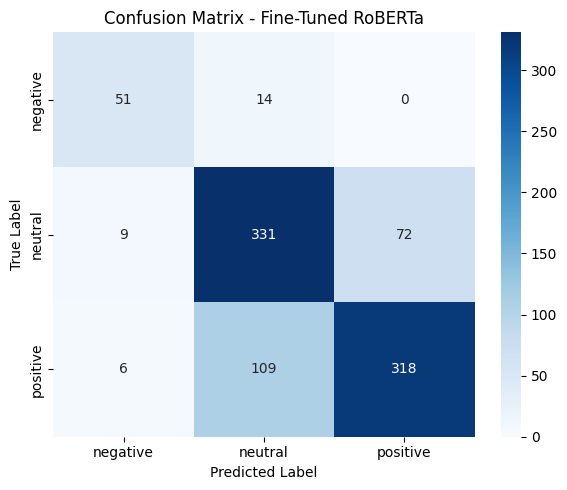

In [8]:
# VALIDATION METRICS + CONFUSION MATRICES FOR BEST SAVED ROBERTA MODEL

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    matthews_corrcoef
)
import seaborn as sns
import matplotlib.pyplot as plt

def compute_metrics_full(preds, labels, label_names):
    preds = np.asarray(preds)
    labels = np.asarray(labels)

    acc = accuracy_score(labels, preds)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
    prec_class, rec_class, f1_class, support_class = precision_recall_fscore_support(labels, preds, average=None, zero_division=0)
    mcc = matthews_corrcoef(labels, preds)

    metrics = {
        "accuracy": float(acc),
        "precision_macro": float(prec_macro),
        "recall_macro": float(rec_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(prec_weighted),
        "recall_weighted": float(rec_weighted),
        "f1_weighted": float(f1_weighted),
        "mcc": float(mcc)
    }

    per_class_df = pd.DataFrame({
        "label": label_names,
        "precision": prec_class,
        "recall": rec_class,
        "f1_score": f1_class,
        "support": support_class
    })

    return metrics, per_class_df

def evaluate_model(model, data_loader, device, loss_fn, label_order):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating RoBERTa"):
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(**batch)

            loss = loss_fn(out.logits, batch["labels"])
            total_loss += loss.item()

            probs = torch.softmax(out.logits, dim=1).detach().cpu().numpy()
            preds = probs.argmax(axis=1)
            labels = batch["labels"].detach().cpu().numpy()

            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    avg_loss = total_loss / max(1, len(data_loader))
    metrics, per_class_df = compute_metrics_full(all_preds, all_labels, label_names=label_order)
    cm = confusion_matrix(all_labels, all_preds)

    return {
        "val_loss": avg_loss,
        "metrics": metrics,
        "per_class_df": per_class_df,
        "confusion_matrix": cm,
        "preds": np.array(all_preds),
        "labels": np.array(all_labels)
    }


# Evaluate the model
results = evaluate_model(clf_mdl, val_dl, device, loss_fn, LABEL_ORDER)

# Print Metrics
print("Validation Loss:", round(results["val_loss"], 4))

print("\nOverall Metrics:")
for k, v in results["metrics"].items():
    print(f"{k}: {v:.4f}")

print("\nPer-Class Metrics:")
print(results["per_class_df"])

print("\nClassification Report:\n")
print(classification_report(
    results["labels"],
    results["preds"],
    target_names=LABEL_ORDER,
    digits=4,
    zero_division=0
))

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    results["confusion_matrix"],
    annot=True,
    fmt="d",
    xticklabels=LABEL_ORDER,
    yticklabels=LABEL_ORDER,
    cmap="Blues"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fine-Tuned RoBERTa")
plt.tight_layout()
plt.show()

In [9]:
# Load speeches
df = pd.read_csv(SPEECHES_CSV)
for c in [ID_COL_SPEECHES, DATE_COL_SPEECHES, TEXT_COL_SPEECHES]:
    if c not in df.columns:
        raise ValueError(f"Missing column '{c}' in {SPEECHES_CSV}.")

df[DATE_COL_SPEECHES] = pd.to_datetime(df[DATE_COL_SPEECHES], errors="coerce")
if df[DATE_COL_SPEECHES].isna().any():
    raise ValueError("Some dates could not be parsed. Fix your speeches CSV.")

# Sentence split
df_sent = (df
           .assign(_sents=lambda d: d[TEXT_COL_SPEECHES].fillna("").apply(sent_tokenize))
           .explode("_sents")
           .rename(columns={"_sents":"sentence"})
           .reset_index(drop=True))
df_sent["sentence"] = df_sent["sentence"].fillna("").str.strip()
df_sent = df_sent[df_sent["sentence"].str.len() > 0].copy()

sentences = df_sent["sentence"].tolist()
probs_all = np.zeros((len(sentences), len(LABEL_ORDER)), dtype=np.float32)

# Inference in batches
for i in tqdm(range(0, len(sentences), BATCH_SIZE_SCORE), desc="Scoring sentences"):
    batch = sentences[i:i+BATCH_SIZE_SCORE]
    enc = clf_tok(batch, padding=True, truncation=True, max_length=MAX_LENGTH_SCORE, return_tensors="pt")
    enc = {k: v.to(device) for k,v in enc.items()}
    with torch.no_grad():
        logits = clf_mdl(**enc).logits.detach().cpu().numpy()
    probs = softmax_np(logits)
    probs_all[i:i+len(batch)] = probs

# Map to p_neg, p_neu, p_pos in the fixed order
df_sent["p_neg"] = probs_all[:, 0]
df_sent["p_neu"] = probs_all[:, 1]
df_sent["p_pos"] = probs_all[:, 2]
df_sent["tone"] = df_sent["p_pos"] - df_sent["p_neg"]  # [-1, +1]
pred_idx = probs_all.argmax(axis=1)
df_sent["label"] = [LABEL_ORDER[i] for i in pred_idx]

# Save sentence-level scores
sentences_dir = os.path.join(OUT_DIR, "sentence_level_results")
os.makedirs(sentences_dir, exist_ok=True)

sent_out = os.path.join(sentences_dir, "roberta_sentences_scored.csv")
df_sent[[ID_COL_SPEECHES, DATE_COL_SPEECHES, "sentence", "p_neg", "p_neu", "p_pos", "tone", "label"]].to_csv(sent_out, index=False)

Scoring sentences: 100%|██████████| 1361/1361 [02:58<00:00,  7.63it/s]


'../../00 Cleaned Dataset/02 fine-tuned bert results/sentences_scored.csv'

In [12]:
def share_over(x, thr=0.5): return (x > thr).mean()
def majority_label(x): return x.value_counts().idxmax() if len(x) else "neutral"

agg = (df_sent
       .groupby([ID_COL_SPEECHES, DATE_COL_SPEECHES], as_index=False)
       .agg(tone_mean=("tone","mean"),
            tone_median=("tone","median"),
            pos_share=("p_pos", share_over),
            neg_share=("p_neg", share_over),
            neu_share=("p_neu", share_over),
            n_sent=("sentence","count")))
maj = (df_sent
       .groupby([ID_COL_SPEECHES, DATE_COL_SPEECHES])["label"]
       .apply(majority_label)
       .reset_index(name="label_majority"))

speech_df = agg.merge(maj, on=[ID_COL_SPEECHES, DATE_COL_SPEECHES], how="left")
speech_out = os.path.join(OUT_DIR, "roberta_speeches.csv")
speech_df.to_csv(speech_out, index=False)
speech_out, speech_df.head(10)


('../../00 Cleaned Dataset/02 fine-tuned bert results/roberta_speeches.csv',
    index       Date  tone_mean  tone_median  pos_share  neg_share  neu_share  \
 0      0 2020-03-03   0.475530     0.670695   0.628866   0.082474   0.288660   
 1      1 2020-02-28   0.413157     0.464932   0.496000   0.048000   0.416000   
 2      2 2020-02-27   0.492258     0.687795   0.671875   0.093750   0.226562   
 3      3 2020-02-06   0.407027     0.571237   0.568182   0.090909   0.272727   
 4      4 2020-01-31   0.168600     0.094093   0.050000   0.000000   0.950000   
 5      5 2020-01-30   0.441260     0.487558   0.494186   0.040698   0.441860   
 6      6 2020-01-28   0.559331     0.730383   0.644628   0.033058   0.314050   
 7      7 2020-01-24   0.569491     0.727582   0.671429   0.028571   0.285714   
 8      8 2020-01-21   0.215888     0.213336   0.212121   0.060606   0.696970   
 9      9 2020-01-09   0.466288     0.639387   0.558824   0.066176   0.367647   
 
    n_sent label_majority  
 0

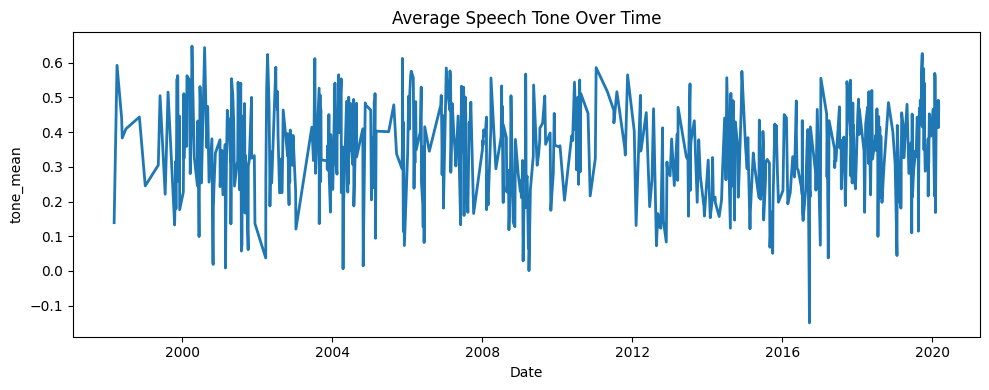

In [13]:
import matplotlib.pyplot as plt

daily = (speech_df.groupby(DATE_COL_SPEECHES, as_index=False)["tone_mean"].mean().sort_values(DATE_COL_SPEECHES))
plt.figure(figsize=(10,4))
plt.plot(daily[DATE_COL_SPEECHES], daily["tone_mean"], linewidth=2)
plt.title("Average Speech Tone Over Time")
plt.xlabel("Date"); plt.ylabel("tone_mean"); plt.tight_layout(); plt.show()


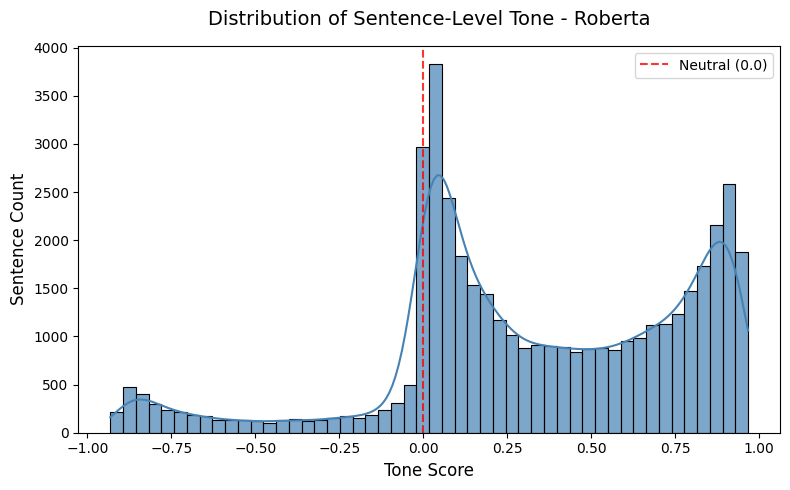

In [14]:
MODEL_PREFIX = "roberta"

sentences_dir = os.path.join(OUT_DIR, "sentence_level_results")
sent_csv_path = os.path.join(sentences_dir, f"{MODEL_PREFIX}_sentences_scored.csv")

# Load the data
df_sent_plot = pd.read_csv(sent_csv_path)

plt.figure(figsize=(8, 5))

sns.histplot(
    df_sent_plot["tone"],
    bins=50,
    kde=True,
    color="steelblue",
    edgecolor="black",
    alpha=0.7
)

plt.title(f"Distribution of Sentence-Level Tone - {MODEL_PREFIX.capitalize()}", fontsize=14, pad=15)
plt.xlabel("Tone Score", fontsize=12)
plt.ylabel("Sentence Count", fontsize=12)

plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label="Neutral (0.0)")
plt.legend()

plt.tight_layout()
plt.show()

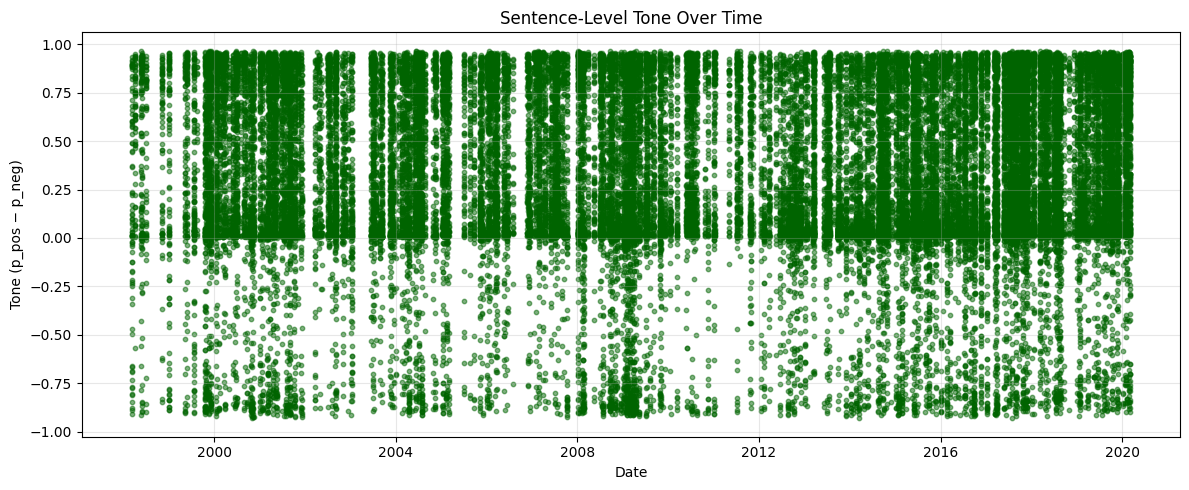

In [15]:
df_sent["Date"] = pd.to_datetime(df_sent["Date"], errors="coerce")

plt.figure(figsize=(12,5))
plt.scatter(df_sent["Date"], df_sent["tone"], s=10, alpha=0.5, color="darkgreen")
plt.title("Sentence-Level Tone Over Time")
plt.xlabel("Date")
plt.ylabel("Tone (p_pos − p_neg)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

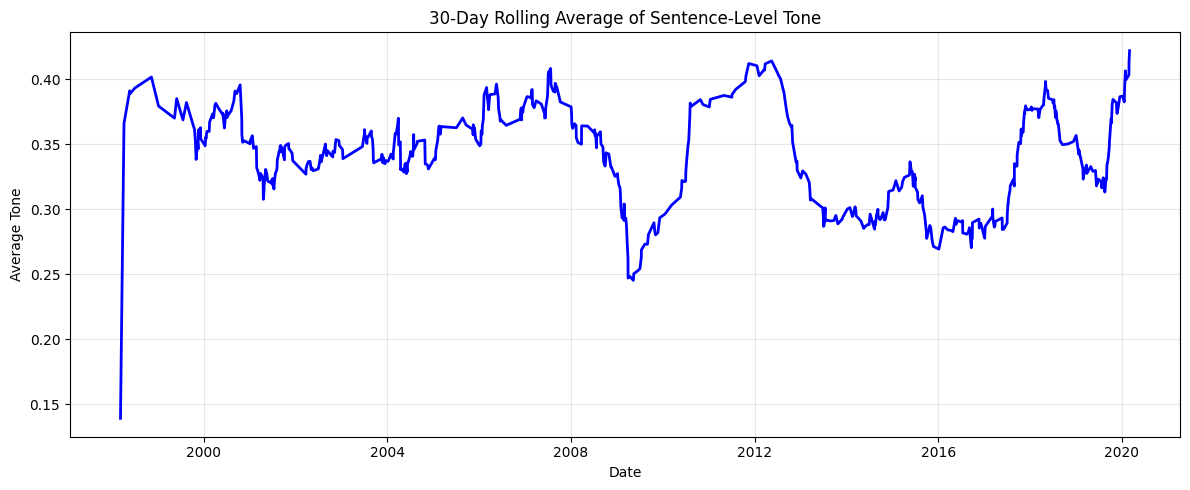

In [16]:
# Rolling average (30-day window)
daily_mean = df_sent.groupby("Date")["tone"].mean().rolling(30, min_periods=1).mean()
plt.figure(figsize=(12,5))
plt.plot(daily_mean.index, daily_mean.values, color="blue", linewidth=2)
plt.title("30-Day Rolling Average of Sentence-Level Tone")
plt.xlabel("Date")
plt.ylabel("Average Tone")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

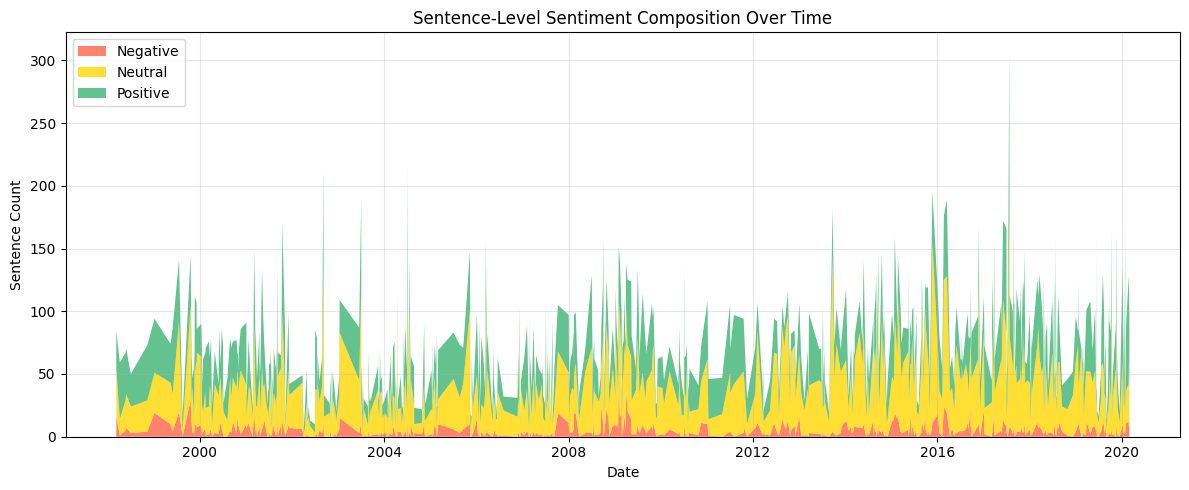

In [17]:
label_counts = (
    df_sent.groupby(["Date", "label"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

plt.figure(figsize=(12,5))
plt.stackplot(
    label_counts.index,
    [label_counts["negative"], label_counts["neutral"], label_counts["positive"]],
    labels=["Negative","Neutral","Positive"],
    colors=["tomato","gold","mediumseagreen"],
    alpha=0.8
)
plt.title("Sentence-Level Sentiment Composition Over Time")
plt.xlabel("Date")
plt.ylabel("Sentence Count")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

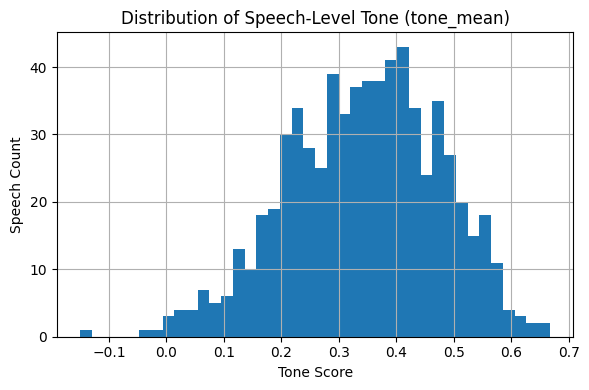

In [18]:
plt.figure(figsize=(6,4))
speech_df["tone_mean"].hist(bins=40)
plt.title("Distribution of Speech-Level Tone (tone_mean)")
plt.xlabel("Tone Score"); plt.ylabel("Speech Count")
plt.tight_layout(); plt.show()